# Customer Churn Prediction Model

This notebook builds a machine learning model to predict customer churn based on transactional and delivery performance features.

The goal is to identify high-risk customers and enable targeted retention strategies.

In [0]:
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%restart_python

In [0]:
import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import roc_auc_score, accuracy_score
from xgboost                 import XGBClassifier
import matplotlib.pyplot     as plt
import warnings
warnings.filterwarnings('ignore')

LOAD DATA AND CONVERT TO PANDAS

In [0]:
df = spark.table("workspace.gold.mart_customer_churn_features").toPandas()

print(f"Shape: {df.shape}")
print(f"Churn rate: {df.is_churned.mean():.2%}")

Shape: (93358, 14)
Churn rate: 70.66%


## Dataset Overview

- Source: Gold layer (`mart_customer_churn_features`)
- Each row represents a unique customer
- Target variable: `is_churned`

We observe the class distribution below.

In [0]:
df.head(10)

,customer_unique_id,customer_state,total_orders,lifetime_value,avg_order_value,avg_delivery_days,avg_delivery_delay,pct_orders_late,avg_review_score,pct_low_reviews,days_since_last_order,delay_dissatisfaction_score,is_churned,_model_run_at
0,c6f624cf0e9908fe310d59a80350bea0,MG,1,87.90,87.90,16.0,-35.0,0.0,5.0,0.0,627,0.0,1,2026-03-26 04:54:44.498144
1,98e71752819916789567071c52c4239e,RJ,1,186.19,186.19,50.0,12.0,100.0,1.0,100.0,221,48.0,1,2026-03-26 04:54:44.498144
2,04373f7c105c306e9bdae55e5c70163c,SP,1,133.75,133.75,3.0,-13.0,0.0,5.0,0.0,190,0.0,1,2026-03-26 04:54:44.498144
3,d28e54a9487cb4d360a09e7a96681e20,SP,1,86.15,86.15,16.0,-3.0,0.0,5.0,0.0,227,0.0,1,2026-03-26 04:54:44.498144
4,d3391cadc57741a0defe8a569e476813,RJ,1,54.13,54.13,25.0,-14.0,0.0,5.0,0.0,159,0.0,0,2026-03-26 04:54:44.498144
5,26ffd81154d2a5dbe5cae3dce93289bd,SP,1,39.39,39.39,4.0,-7.0,0.0,5.0,0.0,131,0.0,0,2026-03-26 04:54:44.498144
6,02f3cc68f02f665daf830cbde5fbe0f8,PR,1,34.00,34.00,10.0,-18.0,0.0,4.0,0.0,253,-18.0,1,2026-03-26 04:54:44.498144
7,e6e8ea2a2c2e768f5824ef27196ed655,SC,1,80.29,80.29,14.0,-9.0,0.0,5.0,0.0,71,0.0,0,2026-03-26 04:54:44.498144
8,c76c0ebec1c44b44dca88e42b23149f1,BA,1,58.70,58.70,21.0,-13.0,0.0,4.0,0.0,552,-13.0,1,2026-03-26 04:54:44.498144
9,861eff4711a542e4b93843c6dd7febb0,SP,1,146.87,146.87,9.0,-11.0,0.0,4.0,0.0,519,-11.0,1,2026-03-26 04:54:44.498144


## CLASS DISTRIBUTION

BASIC EDA (check Class Imbalance)

Target column is is_churned i.e. customer churned or not, taht we are trying to predict

In [0]:
df['is_churned'].value_counts()

is_churned
1    65963
0    27395
Name: count, dtype: int64

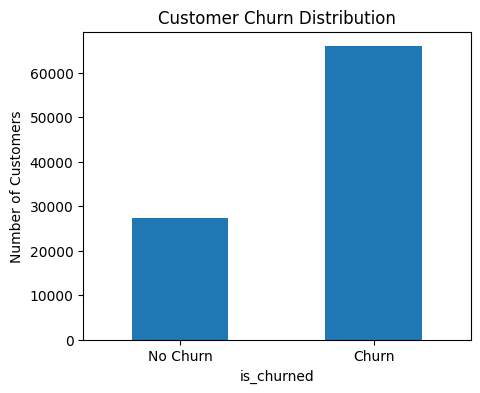

In [0]:
import matplotlib.pyplot as plt

counts = df['is_churned'].value_counts().sort_index()

plt.figure(figsize=(5,4))
counts.plot(kind='bar')

plt.xticks([0,1], ['No Churn', 'Churn'], rotation=0)
plt.title('Customer Churn Distribution')
plt.ylabel('Number of Customers')

plt.show()

We see moderate class imbalance (~70% non-churn, 30% churn). We will use Stratified Splitting in Train-test split.

We will use balance class weight in logistic regression model.

XGBosst handles moderate imbalances well.

## Feature Engineering

We exclude:
- Identifiers (customer_unique_id)
- Metadata (_model_run_at)
- Leakage feature (days_since_last_order)

Selected features capture:
- Customer value
- Delivery performance
- Satisfaction indicators

In [0]:
# FEATURE SELECTION
# Input features used to train the model are chosen

FEATURES = [
    'total_orders', 'lifetime_value', 'avg_order_value',
    'avg_delivery_days', 'avg_delivery_delay', 'pct_orders_late',
    'avg_review_score', 'pct_low_reviews',
    'delay_dissatisfaction_score',
]
# I didn't keep 'days_since_last_order' as features as it causes target leakage, because model learns that if days_since_last_order > 180 → churn = 1  .. thus accuracy and AUD becomes 100%, which means model won't learn.

TARGET = 'is_churned'

X = df[FEATURES].fillna(0)
y = df[TARGET]

In [0]:
X.head(10)

,total_orders,lifetime_value,avg_order_value,avg_delivery_days,avg_delivery_delay,pct_orders_late,avg_review_score,pct_low_reviews,delay_dissatisfaction_score
0,1,87.90,87.90,16.0,-35.0,0.0,5.0,0.0,0.0
1,1,186.19,186.19,50.0,12.0,100.0,1.0,100.0,48.0
2,1,133.75,133.75,3.0,-13.0,0.0,5.0,0.0,0.0
3,1,86.15,86.15,16.0,-3.0,0.0,5.0,0.0,0.0
4,1,54.13,54.13,25.0,-14.0,0.0,5.0,0.0,0.0
5,1,39.39,39.39,4.0,-7.0,0.0,5.0,0.0,0.0
6,1,34.00,34.00,10.0,-18.0,0.0,4.0,0.0,-18.0
7,1,80.29,80.29,14.0,-9.0,0.0,5.0,0.0,0.0
8,1,58.70,58.70,21.0,-13.0,0.0,4.0,0.0,-13.0
9,1,146.87,146.87,9.0,-11.0,0.0,4.0,0.0,-11.0


In [0]:
y.head(10)

0    1
1    1
2    1
3    1
4    0
5    0
6    1
7    0
8    1
9    1
Name: is_churned, dtype: int32

## TRAIN-TEST SPLIT

In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # IMPORTANT (handles class imbalance)
)

## Baseline Model — Logistic Regression

In [0]:
mlflow.set_experiment('/olist_churn_model')

with mlflow.start_run(run_name='logistic_regression_balanced'):

    # 🔹 Scaling required for LR
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # 🔹 Model with class imbalance handling
    lr = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'   # ⭐ THIS fixes imbalance
    )
    lr.fit(X_train_sc, y_train)

    # 🔹 Predictions
    y_pred  = lr.predict(X_test_sc)
    y_proba = lr.predict_proba(X_test_sc)[:, 1]

    # 🔹 Metrics
    auc      = roc_auc_score(y_test, y_proba)
    accuracy = accuracy_score(y_test, y_pred)

    # 🔹 Log to MLflow
    mlflow.log_param('model_type', 'logistic_regression')
    mlflow.log_param('max_iter', 1000)
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_metric('roc_auc', round(auc, 4))
    mlflow.log_metric('accuracy', round(accuracy, 4))

    # 🔹 Log model
    mlflow.sklearn.log_model(lr, 'logistic_regression_model')

    print(f'LR (balanced) → AUC: {auc:.4f} | Accuracy: {accuracy:.4f}')

2026/03/26 04:58:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-0b99ec5d-e1bd.cloud.databricks.com/ml/experiments/2633841617167666/models/m-09687d1199804fdbb08ea3f3a3ab9969?o=238405111739211
2026/03/26 04:59:04 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


LR (balanced) → AUC: 0.6702 | Accuracy: 0.5957


- AUC: ~0.67
- Accuracy: ~0.59

This serves as a baseline model.
Performance is moderate, indicating limited linear separability of churn patterns.

AUC of 0.67 means LR Model can correctly rank a churned customer higher than a non-churned one ~67% of the time.

## XGBOOST Model

This is the main model.

In [0]:
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt

xgb_params = {
    'n_estimators': 200,
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'use_label_encoder': False,
    'eval_metric': 'logloss',
}

with mlflow.start_run(run_name='xgboost_primary'):

    xgb = XGBClassifier(**xgb_params)
    xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    y_pred  = xgb.predict(X_test)
    y_proba = xgb.predict_proba(X_test)[:, 1]

    auc      = roc_auc_score(y_test, y_proba)
    accuracy = accuracy_score(y_test, y_pred)

    # Save for registry later
    auc_on_holdout = auc

    # 🔹 Log params + metrics
    for k, v in xgb_params.items():
        mlflow.log_param(k, v)

    mlflow.log_metric('roc_auc', round(auc, 4))
    mlflow.log_metric('accuracy', round(accuracy, 4))

    # 🔹 Feature importance
    feat_imp = pd.Series(
        xgb.feature_importances_,
        index=FEATURES
    ).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    feat_imp.plot(kind='barh', ax=ax)
    ax.set_title('XGBoost Feature Importance')

    mlflow.log_figure(fig, 'feature_importance.png')
    plt.close()

    from mlflow.models.signature import infer_signature

    # Create signature
    signature = infer_signature(X_train, xgb.predict(X_train))

    mlflow.sklearn.log_model(
        xgb,
        'xgboost_churn_model',
        signature=signature
    )

    print(f'XGB → AUC: {auc:.4f} | Accuracy: {accuracy:.4f}')

2026/03/26 04:59:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-0b99ec5d-e1bd.cloud.databricks.com/ml/experiments/2633841617167666/models/m-4815f78a19744c9eb1ef027cca857f5e?o=238405111739211


XGB → AUC: 0.7189 | Accuracy: 0.7419


- AUC: ~0.72
- Accuracy: ~0.74

AUC of 0.72 means XGBoost Model can correctly rank a churned customer higher than a non-churned one ~72% of the time.



CONFUSION MATRIX OF XGBOOST

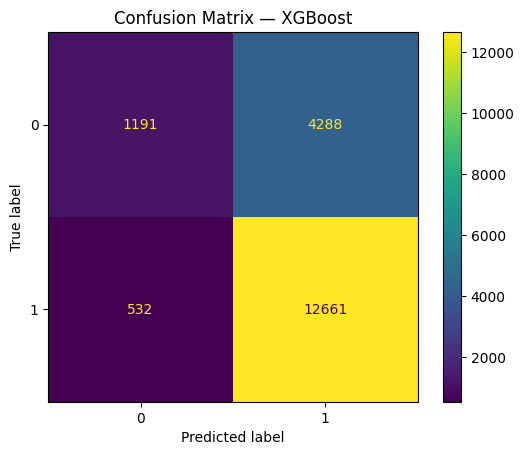

In [0]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix — XGBoost")
plt.show()

The confusion matrix shows the model's ability to correctly classify churn and non-churn customers.

This helps evaluate false positives (unnecessary interventions) vs false negatives (missed churn risk).

The model correctly identifies 12,686 churned customers (True Positives) but also flags 4,250 non-churn customers as churn (False Positives).

This indicates the model is more aggressive in identifying churn, which is acceptable for retention-focused strategies.

In churn use-cases, Recall is more important that Precision.

We can tune the threshold value (currently 0.5 is default value for xgboost) if we want to reduce false positives further.

## Feature Importance

In [0]:
    print('\nTop Features:')
    print(feat_imp.head())


Top Features:
avg_delivery_days     0.278554
pct_orders_late       0.207136
avg_delivery_delay    0.197806
pct_low_reviews       0.104980
avg_review_score      0.053863
dtype: float32


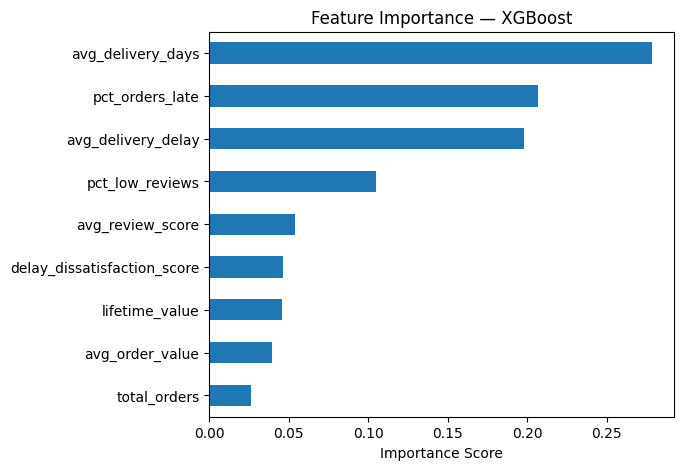

In [0]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    xgb.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(6,5))
feat_imp.plot(kind='barh')

plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')

plt.show()

Key drivers of churn:

- Delivery delays
- Late order percentage
- Delivery duration in days

This indicates that operational inefficiencies strongly impact customer retention.

The feature values are the relative importance of the features compared to other features in the decisioning power of the XGBoost Model.
i.e. Feature's contribution to model splits / Total number of decisions

For e.g. avg_delivery_days = 0.30 means ~30% of model decisions rely on delivery days feature relative to others.

## Business Insight

Customers experiencing delayed or inconsistent deliveries are significantly more likely to churn.

This suggests that improving logistics performance can directly reduce churn rates.


## Logistic Regression vs XGBoost Model Comparison


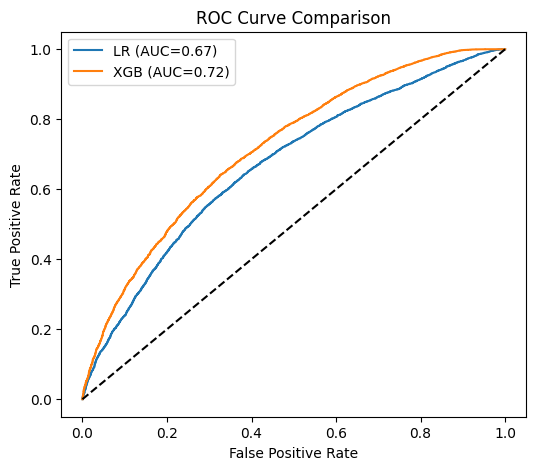

In [0]:
from sklearn.metrics import roc_curve

# Logistic Regression probs
y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]

# XGBoost probs (already have)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC={roc_auc_score(y_test, y_proba_lr):.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC={roc_auc_score(y_test, y_proba_xgb):.2f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

The ROC curve shows that XGBoost outperforms Logistic Regression, as it is able to better capture non-linear relationships in customer behavior, indicating better ability to distinguish churned vs non-churned customers.

## Customer Scoring Output

The model generates churn probabilities for all customers and stores their churn results in the Delta table:

`workspace.gold.customer_churn_scores`

This table can be used for:
- Targeted marketing campaigns
- Customer retention strategies
- Dashboard visualisation

In [0]:
df_all = spark.table("workspace.gold.mart_customer_churn_features").toPandas()

X_all = df_all[FEATURES].fillna(0)

churn_proba = xgb.predict_proba(X_all)[:, 1]

import pandas as pd

scores_df = pd.DataFrame({
    'customer_unique_id': df_all['customer_unique_id'],
    'churn_probability' : churn_proba.round(4),
    'churn_risk_band'   : pd.cut(
        churn_proba,
        bins=[0, 0.3, 0.6, 1.0],
        labels=['Low', 'Medium', 'High']
    ).astype(str),
    'actual_is_churned' : df_all['is_churned'],
    'model_version'     : 'xgboost_v1',
    'scored_at'         : pd.Timestamp.now()
})

(
    spark.createDataFrame(scores_df)
    .write
    .format('delta')
    .mode('overwrite')
    .saveAsTable("workspace.gold.customer_churn_scores")
)

print(f"Scored {len(scores_df):,} customers")

Scored 93,358 customers


VERIFY SOME CHURN SCORES

In [0]:
%sql
select * 
from workspace.gold.customer_churn_scores
limit 10

customer_unique_id,churn_probability,churn_risk_band,actual_is_churned,model_version,scored_at
8d6392346695368fdacf2ba5bc70e5b4,0.1089,Low,0,xgboost_v1,2026-03-26T04:59:14.474Z
0d26ad97e4a962687ed81659eff0e3fb,0.6518,High,1,xgboost_v1,2026-03-26T04:59:14.474Z
16a5eb747c0c944a0854193b5a8a1443,0.7926,High,1,xgboost_v1,2026-03-26T04:59:14.474Z
b954441f78c6bbf47ab3e6aa0b9b1a2a,0.6104,High,1,xgboost_v1,2026-03-26T04:59:14.474Z
2beca05a77d050fe5cf749423d30e04b,0.5933,Medium,0,xgboost_v1,2026-03-26T04:59:14.474Z
a1cf0b1b6d8bdb6170db08446546b6f5,0.8076,High,1,xgboost_v1,2026-03-26T04:59:14.474Z
4399f1c9b351d4c09e167b8ce3d8da76,0.54,Medium,0,xgboost_v1,2026-03-26T04:59:14.474Z
56e615697258bdade82ec5d0bf6996a4,0.5086,Medium,0,xgboost_v1,2026-03-26T04:59:14.474Z
f6cc987aff14cd5525d0302701942722,0.8059,High,1,xgboost_v1,2026-03-26T04:59:14.474Z
aae157df342350f9cbdda0faac9d83ce,0.6292,High,1,xgboost_v1,2026-03-26T04:59:14.474Z


## Business Insight

Medium and High Churn Score Customers -> Fix Logistics

Low Churn Score Customers -> Send new product offers
